**mileage**

In dezef file zullen we de tests uitvoeren om mileage te optamaliseren. In deze files worden dus testen uitgevoerd om die code te gebruiken om het hoofdprogramma

Een groot deel van de error komt door mileage_km. in de kolom mileage is een groot deel dat veel te grote getallen hebben. dit trekt het gemiddelde serieus omhoog wat zorgt voor heel slechte data. we zullen proberen te zien dat we dit kunnen fixen aan de hand door het checken met andere parameters.

**hoe beginnen we**

aangezien er zoveel hoge getallen zijn zullen we eerts is een bare minimum van 800000 pakken en zien hoeveel er boven dat getal zijn

In [346]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# read csv file
dft = pd.read_csv('../../csv/new_train_data/train_CarBreakDown.csv')
high_mileage_count = (dft['mileage_km'] > 500000).sum()
print(f"Number of vehicles with mileage above 200,000 km: {high_mileage_count}")


Number of vehicles with mileage above 200,000 km: 6


**wat zien we**

zoals hierboven zichtbaar zijn er veel die boven de 800000 km zijn, maar wat is de rede hiervoor. Wij denken dat er de mogelijkheid was dat de komma's bij deze getallen verkeerd zijn ingevuld. hoe gaan we dit checken? We zullen beginnne met eerst de max en min te laten zien

In [347]:
# Laat de 10 hoogste mileage voertuigen zien, maar alleen met de gewenste kolommen
top_10_mileage = dft.sort_values(by='mileage_km', ascending=False).head(10)
print(top_10_mileage[['id', 'vehicle_brand', 'vehicle_age_years', 'mileage_km']])

       id vehicle_brand  vehicle_age_years     mileage_km
596   192         other                3.0  952591.000000
662   765    Volkswagen                6.0  676797.381249
880  1036           BMW               16.0  575052.812672
176   103       Renault                7.0  549929.400509
433   873           BMW               20.0  542738.263249
34    760           Kia                6.0  528795.480402
598   435    Volkswagen               12.0  494730.335874
728   738        Toyota               18.0  436687.184724
74    829          Ford                5.0  424598.250991
267  1275    Volkswagen                6.0  414253.050932


hierboven zien we dat er nog steeds wat files zijn met veel kilometers. We zullen een boxplot gebruiken om te kijken als er de mogelijkeheid is dat er in deze data een typfout staat of dat de data niet kan gebruikt worden.

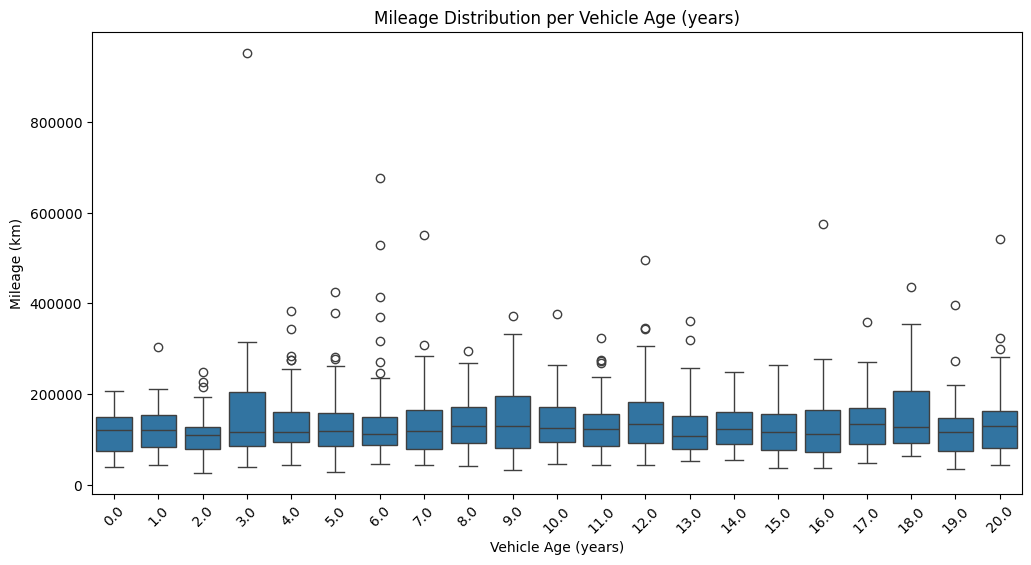

In [348]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='vehicle_age_years', y='mileage_km', data=dft)
plt.title("Mileage Distribution per Vehicle Age (years)")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Mileage (km)")
plt.xticks(rotation=45)  # optioneel, draait labels voor betere leesbaarheid
plt.show()

Deze data klopt helemaal niet. auto's die nog geen jaar oud zijn hebben een mediaan van 120000, maar hoe exact fixen we dit. Wij als groep zijn hier niet uitgekomen. Dit doen we omdat de data zo fout is en we wisten nie hoe we hier uit moesten komen.

**last_service_km**

net zoals mileage heeft deze ook zen problemen. in de code hieronder maken we een boxplot om te zien dat er veel outliers zijn. een van onze ideeen was om alle outliers van 0 oftewel niet kapot weg te halen. dit verhoogt de kans dat hij gaat zeggen dat die kapot gaat zijn, maar als gevolg gaat de accuraatheid omlaag omdat hij het niet meer met zekerheid kan zeggen.

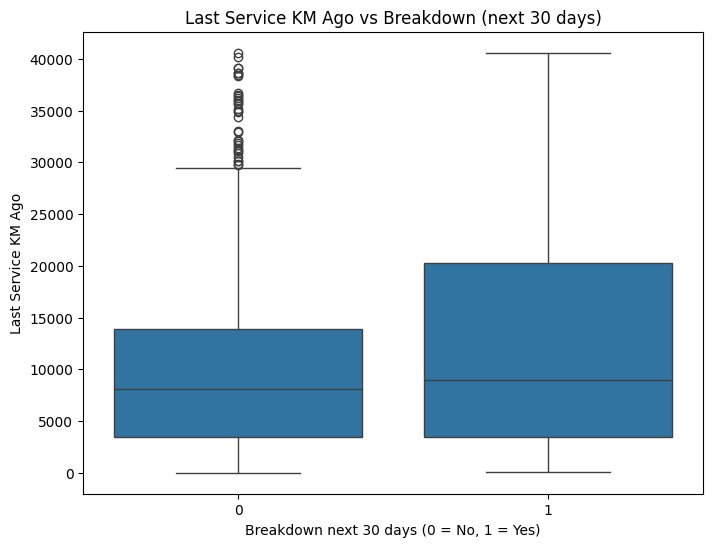

In [349]:


# # Plot
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='breakdown_next_30_days', y='mileage_km', data=dft)
# plt.title("Mileage KM vs Breakdown (next 30 days)")
# plt.xlabel("Breakdown next 30 days (0 = No, 1 = Yes)")
# plt.ylabel("Mileage KM")
# plt.show()

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='breakdown_next_30_days', y='last_service_km_ago', data=dft)
plt.title("Last Service KM Ago vs Breakdown (next 30 days)")
plt.xlabel("Breakdown next 30 days (0 = No, 1 = Yes)")
plt.ylabel("Last Service KM Ago")
plt.show()
# Verwijder outliers in last_service_km_ago voor breakdown = 0
mask = (dft['breakdown_next_30_days'] == 0) & (dft['last_service_km_ago'] > 27000)
dft = dft[~mask]


Je kunt aan deze data zien dat dit helemaal niet klopt. maar hoe komt dit? heel veel slechte data of heeft vehicle_age_years helemaal geen correlatie tot de mileage in deze csv file? we zullen is testen als er correlatie is tussen mileage een years. hieronder is zichtbaar dat er eig geen correlatie is tusse iets behalve mileage and engine hours. 

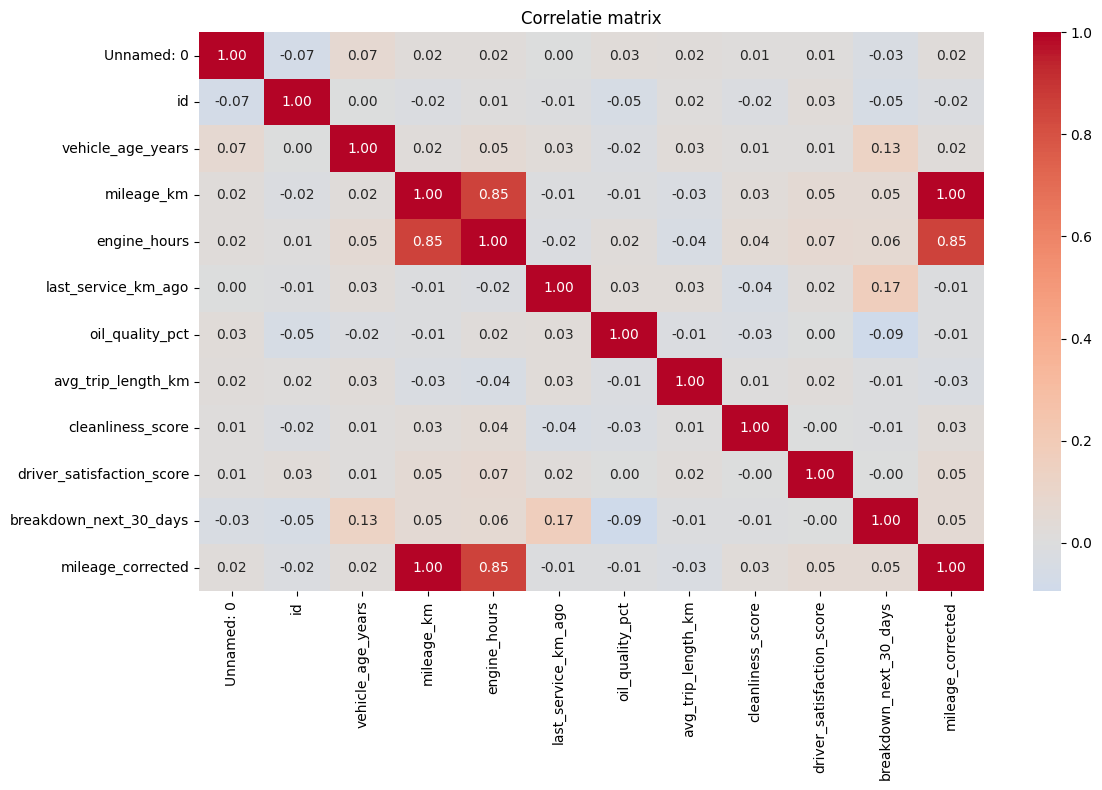

In [350]:
# Blok 1
dft['mileage_corrected'] = dft['mileage_km'] 


# Blok 2 - los eronder
numeric_cols = dft.select_dtypes(include='number')  # ook dft ipv df!

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlatie matrix')
plt.tight_layout()
plt.show()



In [352]:
# mileage_km = df['mileage_km']

# print("Kollom snel overzicht: \n")
# print(f"Kollom null waardes: {mileage_km.isnull().sum()} ({(mileage_km.isnull().sum()/totaal_records * 100).round(2)}%)")
# print(f"Kollom gemiddelde: {mileage_km.mean()}")
# print(f"Kollom median: {mileage_km.median()}")
# print(f"Kollom uitschieters: {len(df[(df['mileage_km'] >df['mileage_km'].mean() + df['mileage_km'].std()*2) | (df['mileage_km'] < df['mileage_km'].mean() - df['mileage_km'].std()*2)])}")
# print(f"Kollom 95% quantile boven aantal: {len(df[df['mileage_km'] > df['mileage_km'].quantile(0.95)])}")

# print(df['mileage_km'].mean() + df['mileage_km'].std()*2)
# # sns.violinplot(data=df, y='mileage_km')
# sns.boxplot(data=df[(df['mileage_km'] < df['mileage_km'].quantile(0.95))], y='mileage_km') 

# df.loc[df['mileage_km'] > df['mileage_km'].quantile(0.95), 'mileage_km'] = df.loc[df['mileage_km'] > df['mileage_km'].quantile(0.95), 'vehicle_age_years'] * df['mileage_km'].median() # replace values above 95% quantile with there age because if the vehicle is used longer the mileage should be higher, 120361 is the median and most accurate measure because a car driven 10 years has about 120 000 km mileage, assuming there relation is linear we can multiply them, given them an average value and prevent droppping 51 records

# df.loc[df['mileage_km'] < 0, 'mileage_km'] = df.loc[df['mileage_km'] < 0, 'vehicle_age_years'] * df['mileage_km'].median()  # replace negative values with age times median because negative mileage does not exist, and saves 1 record

# df.loc[df['mileage_km'].isnull(), 'mileage_km'] = df.loc[df['mileage_km'].isnull(), 'vehicle_age_years'] * df['mileage_km'].median()  # replace null values with age times median

# df = df.drop(df[(df['mileage_km'] > df['mileage_km'].mean()) & (df['vehicle_age_years'] < 3)].index) # drop records which have cars that are less then two years old and have a mileage higher then the mean


#  print("\nAlgemene Data Na aanpassing")
# print(df['mileage_km'].describe())
# df